# 🌲 RandomForest com ranger em R
*Machine Learning - Ciência de Dados*

**Dataset:** Iris (versão 3 classes)
**Pacotes:** ranger, ggplot2, dplyr, vip, yardstick

In [1]:
# Carregar bibliotecas
library(ranger)      # Random Forest
library(ggplot2)     # Visualização
library(dplyr)       # Manipulação
library(vip)         # Feature Importance
library(yardstick)   # Métricas

cat("✓ Pacotes carregados!\n")


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





Attaching package: ‘vip’




The following object is masked from ‘package:utils’:

    vi




✓ Pacotes carregados!


## 1. Carregar Dados Iris

In [2]:
df <- iris
names(df) <- c("Sepal.Length", "Sepal.Width", 
               "Petal.Length", "Petal.Width", "Species")
head(df)
str(df)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...


## 2. Preparar Features e Target

In [3]:
features <- c("Sepal.Length", "Sepal.Width", 
              "Petal.Length", "Petal.Width")
X <- df[, features]
y <- as.factor(df$Species)

cat("Features:", features, "\n")
cat("Classes:", levels(y), "\n")

Features: Sepal.Length Sepal.Width Petal.Length Petal.Width 


Classes: setosa versicolor virginica 


## 3. Divisão Treino/Teste (75/25)

In [4]:
set.seed(42)
n <- nrow(X)
train_idx <- sample(1:n, size = 0.75 * n)

X_train <- X[train_idx, ]
X_test  <- X[-train_idx, ]
y_train <- y[train_idx]
y_test  <- y[-train_idx]

cat("Treino:", length(y_train), "amostras\n")
cat("Teste:", length(y_test), "amostras\n")

Treino: 112 amostras


Teste: 38 amostras


## 4. Treinar RandomForest (ranger)

In [5]:
set.seed(42)
rf_model <- ranger(
  x = X_train, 
  y = y_train,
  num.trees = 500,
  mtry = sqrt(ncol(X)),
  importance = 'permutation'
)

print(rf_model)
cat("\nOOB Error:", round(rf_model$prediction.error * 100, 2), "%\n")

Ranger result

Call:
 ranger(x = X_train, y = y_train, num.trees = 500, mtry = sqrt(ncol(X)),      importance = "permutation") 

Type:                             Classification 
Number of trees:                  500 
Sample size:                      112 
Number of independent variables:  4 
Mtry:                             2 
Target node size:                 1 
Variable importance mode:         permutation 
Splitrule:                        gini 
OOB prediction error:             6.25 % 



OOB Error: 6.25 %


## 5. Feature Importance

Importance:


 Petal.Width Petal.Length Sepal.Length  Sepal.Width 
 0.303317817  0.296082344  0.034103889  0.005500878 


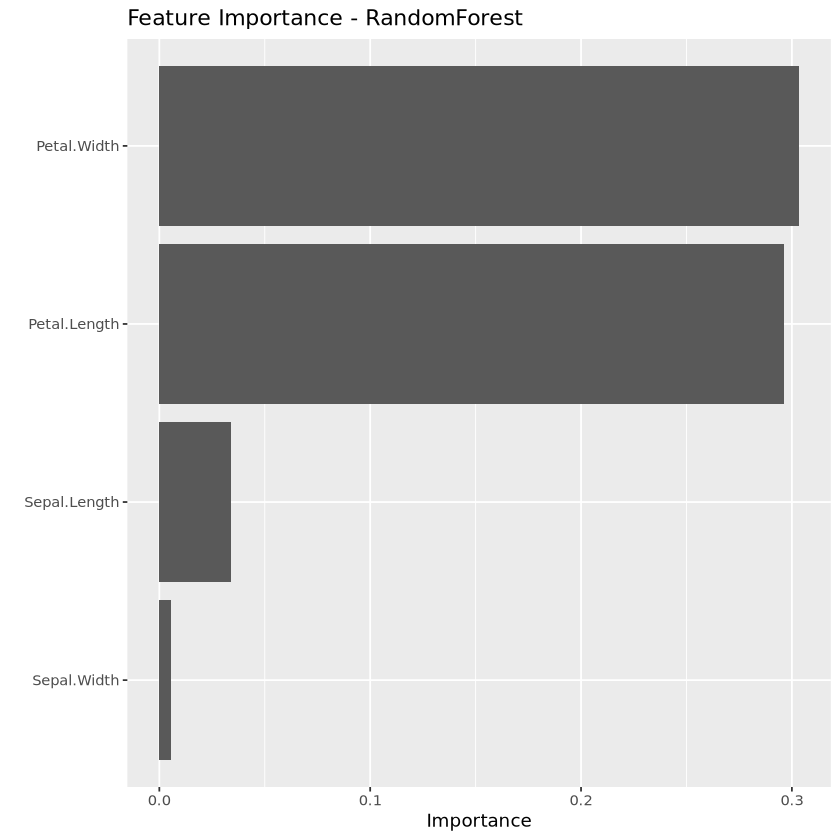

In [6]:
# Importância das features
imp <- importance(rf_model)
cat("Importance:\n")
print(sort(imp, decreasing = TRUE))

# Visualização
vip(rf_model) + ggtitle("Feature Importance - RandomForest")

## 6. Predição e Avaliação

In [7]:
# Predizer
y_pred <- predict(rf_model, X_test)$predictions

# Matriz de confusão
cat("Matriz de Confusão:\n")
print(table(Previsto = y_pred, Real = y_test))

# Acurácia
acc <- sum(y_pred == y_test) / length(y_test)
cat("\nAcurácia:", round(acc * 100, 2), "%\n")

Matriz de Confusão:


            Real
Previsto     setosa versicolor virginica
  setosa         11          0         0
  versicolor      0         11         1
  virginica       0          1        14



Acurácia: 94.74 %


## 7. Validação Cruzada 5-fold

In [8]:
set.seed(42)
folds <- sample(rep(1:5, length.out = nrow(X)))

cv_scores <- sapply(1:5, function(fold) {
  test_idx <- which(folds == fold)
  X_tr <- X[-test_idx, ]; X_te <- X[test_idx, ]
  y_tr <- y[-test_idx];   y_te <- y[test_idx]
  
  rf <- ranger(x = X_tr, y = y_tr, num.trees = 100)
  yp <- predict(rf, X_te)$predictions
  sum(yp == y_te) / length(y_te)
})

cat("CV Scores:", round(cv_scores * 100, 2), "%\n")
cat("CV Média:", round(mean(cv_scores) * 100, 2), "%\n")
cat("CV Desvio:", round(sd(cv_scores) * 100, 2), "%\n")

CV Scores: 86.67 96.67 96.67 93.33 96.67 %


CV Média: 94 %


CV Desvio: 4.35 %


## 8. Conclusão

In [9]:
cat("═══════════════════════════════════════\n")
cat("      RESULTADOS RANDOMFOREST (ranger)  \n")
cat("═══════════════════════════════════════\n")
cat("Modelo:", rf_model$mtry, "mtry,", rf_model$num.trees, "árvores\n")
cat("Acurácia (teste):", round(acc * 100, 2), "%\n")
cat("CV 5-fold média:  ", round(mean(cv_scores) * 100, 2), "%\n")
cat("OOB Error:        ", round(rf_model$prediction.error * 100, 2), "%\n")
cat("═══════════════════════════════════════\n")

cat("\nFeature mais importante:", 
    names(which.max(importance(rf_model))), "\n")

═══════════════════════════════════════


      RESULTADOS RANDOMFOREST (ranger)  


═══════════════════════════════════════


Modelo: 2 mtry, 500 árvores


Acurácia (teste): 94.74 %


CV 5-fold média:   94 %


OOB Error:         6.25 %


═══════════════════════════════════════



Feature mais importante: Petal.Width 
